### Exploratory Data Analysis & Business Insights

##### Category & Spend Analysis

In [2]:
# Importing libraries and Loading the cleaned dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_upi_cleaned = pd.read_csv(r'E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Data\upi_cleaned.csv')

print("Libraries imported & Dataset loaded successfully!")

# Verifying
print(df_upi_cleaned.shape)
df_upi_cleaned.head(5)

Libraries imported & Dataset loaded successfully!
(1000, 16)


,Transaction_ID,Date,Amount,Category,Type,Payment_Mode,Merchant,Notes,Month_Num,Month_Name,Day_of_Week,Week_Number,Spend_Bucket,Is_Weekend,Is_Anomaly,Quarter
0,TXN10523,2024-07-11,4431.86,Education,Need,GPay,Unacademy,Unacademy payment,7,July,Thursday,28,Large,No,No,Q3
1,TXN10602,2024-08-05,247.31,Transport,Need,Paytm,RedBus,RedBus payment,8,August,Monday,32,Small,No,No,Q3
2,TXN10526,2024-07-12,2322.61,Shopping,Want,GPay,Amazon,Amazon payment,7,July,Friday,28,Large,No,No,Q3
3,TXN10031,2024-01-12,4272.21,Shopping,Want,Paytm,Ajio,Ajio payment,1,January,Friday,2,Large,No,No,Q1
4,TXN10616,2024-08-10,1332.70,Shopping,Want,PhonePe,Ajio,Ajio payment,8,August,Saturday,32,Medium,Yes,No,Q3


In [3]:
# Setting visual style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["font.size"] = 12

print("Visual Style Setting is done.")

Visual Style Setting is done.


##### Q1. Which Category has the highest total spending?

In [4]:
# Calculating the Category wise total spending
category_spending = df_upi_cleaned.groupby(
    "Category",
    as_index=False
    )["Amount"].sum().sort_values(by="Amount", ascending=False)

print("Total Spendings by Category: \n",category_spending)

Total Spendings by Category: 
              Category     Amount
7            Shopping  403589.41
10             Travel  292609.64
1           Education  262626.24
4           Groceries  225896.75
0   Bills & Utilities  172361.99
6       Miscellaneous  130772.23
5    Health & Medical   91683.08
3       Food & Dining   90044.94
2       Entertainment   70786.76
9           Transport   37388.83
8       Subscriptions   28497.43


##### Answer Q1: 'Shopping' has the highest total spending of ₹403589.41 followed by Travel with ₹292609.64 and 'Education' with ₹262626.24. It indicates that 'Shopping' has very high overspending than other categories.

##### Q2. Which category has the highest average transaction?

In [5]:
# Category wise average transaction
category_avg_transaction = df_upi_cleaned.groupby(
    "Category", as_index=False
    )["Amount"].mean().sort_values(by="Amount",ascending=False)

print("Category wise Average Transaction: \n",category_avg_transaction.round(2))

Category wise Average Transaction: 
              Category   Amount
10             Travel  5520.94
1           Education  4689.75
7            Shopping  3034.51
0   Bills & Utilities  2238.47
4           Groceries  1821.75
5    Health & Medical  1729.87
6       Miscellaneous  1348.17
2       Entertainment   943.82
8       Subscriptions   569.95
3       Food & Dining   505.87
9           Transport   359.51


##### Answer Q2: 'Travel' category has highest average amount spent. It means there were spending in larger amount at a time during Travel.

##### Q3: What % of total spend does each category represent?

In [6]:
# Calculating % Share of each category in total spending

total_spending = df_upi_cleaned["Amount"].sum()
category_share_pct = ((df_upi_cleaned.groupby("Category")["Amount"].sum() / total_spending) * 100).round(2).sort_values(ascending=False)

print(f"Share% of each category in total spending: \n {category_share_pct}")

Share% of each category in total spending: 
 Category
Shopping             22.34
Travel               16.20
Education            14.54
Groceries            12.51
Bills & Utilities     9.54
Miscellaneous         7.24
Health & Medical      5.08
Food & Dining         4.99
Entertainment         3.92
Transport             2.07
Subscriptions         1.58
Name: Amount, dtype: float64


##### Answer Q3: As we have expected, 'Shopping' has highest share of 22.34% in total spending. Indicating that there was overspending on shopping.

##### Q4. Needs vs Wants — what is the ratio?

In [7]:
# Calculating Needs Vs Wants

Needs_Wants_sum= df_upi_cleaned.groupby("Type")["Amount"].sum()
total = Needs_Wants_sum.sum().round(2)

print("Needs Vs Wants Breakdown:")
print(Needs_Wants_sum)
print(f"\nNeeds: {(Needs_Wants_sum["Need"]/total*100).round(2)}%")
print(f"Wants: {(Needs_Wants_sum["Want"]/total*100).round(2)}%")

Needs Vs Wants Breakdown:
Type
Need    883166.08
Want    923091.22
Name: Amount, dtype: float64

Needs: 48.89%
Wants: 51.11%


##### Answer Q4: Spending was more on fulfilling 'Wants' rather than 'Needs'. There was more spending on 'Wants' category which is 51.11% of total spending. Main culprits were 'Shopping' and 'Travel'

##### Q5.  Which month had worst Wants-to-Needs ratio?

In [8]:
# Month wise Needs Vs Wants breakdown

monthly_type = df_upi_cleaned.groupby(["Month_Num","Month_Name","Type"])["Amount"].sum().unstack()
monthly_type["Wants Ratio"] = (monthly_type["Want"] / (monthly_type["Need"] + monthly_type["Want"])*100).round(2)

print("Monthly Wants Ratio%: ")
print(monthly_type[["Want","Need","Wants Ratio"]].sort_values(by="Wants Ratio",ascending=False))

Monthly Wants Ratio%: 
Type                       Want       Need  Wants Ratio
Month_Num Month_Name                                   
3         March       101135.99   43949.95        69.71
12        December     55495.21   40482.62        57.82
4         April        61192.78   46717.28        56.71
9         September    81968.93   66449.76        55.23
2         February     67747.70   64144.37        51.37
10        October      88856.11   87605.03        50.35
8         August       79646.11   80797.90        49.64
6         June         94486.42   98153.41        49.05
7         July         89754.15  100001.08        47.30
5         May          95018.44  109472.34        46.47
1         January      53912.35   65925.80        44.99
11        November     53877.03   79466.54        40.40


##### Answer Q5: 'March' has worst Wants-to-Need Ratio. May be due to Shopping during Travel in summer vacation. 

##### Q6. Which single Want category should be cut to save most?

In [9]:
# Calculating spending of want categories
want_spending = df_upi_cleaned[
    df_upi_cleaned["Type"]=="Want"
    ].groupby("Category"
              )["Amount"].sum().sort_values(
                  ascending=False)

print("Want Categories by Total Spend: \n",want_spending)

top_want = want_spending.index[0]
top_want_spending = want_spending.iloc[0]
saving_20 = (top_want_spending*0.2).round(2)

print(f"\nHighest Spent Want Categoryis {top_want} with total spending of ₹{top_want_spending}")
print(f"If '{top_want}'s' spend is reduced by 20%:")
print(f"Then Total Saving = ₹{saving_20}")

Want Categories by Total Spend: 
 Category
Shopping         403589.41
Travel           292609.64
Miscellaneous    130772.23
Entertainment     67622.51
Subscriptions     28497.43
Name: Amount, dtype: float64

Highest Spent Want Categoryis Shopping with total spending of ₹403589.41
If 'Shopping's' spend is reduced by 20%:
Then Total Saving = ₹80717.88


##### Answer Q6: As we know 'Shopping' category has most overspending with ₹403589.41 in a year. So if we reduce the spending on shopping by 20%, we can save around ₹80717.88 per year

### VISUALIZATION:

##### Chart 1 - Category wise total spend : Bar Chart 

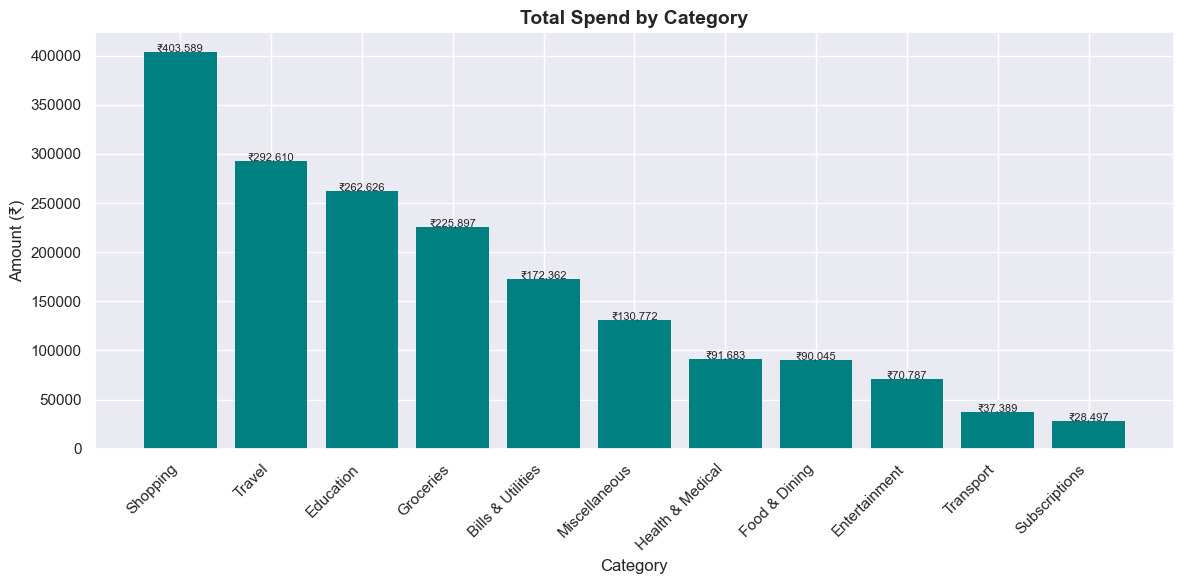

In [10]:
category_spend = df_upi_cleaned.groupby("Category")["Amount"].sum().sort_values(ascending=False).round(2)

plt.figure(figsize=(12,6))
bars = plt.bar(category_spend.index, category_spend.values, color='#008080', edgecolor="none")

# Adding value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 500, 
             f"₹{bar.get_height():,.0f}", 
             ha="center", fontsize=8)
plt.title("Total Spend by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart1_category_spend.png", dpi=150)
plt.show()

##### Chart 2 - Needs vs Wants : Donut Chart

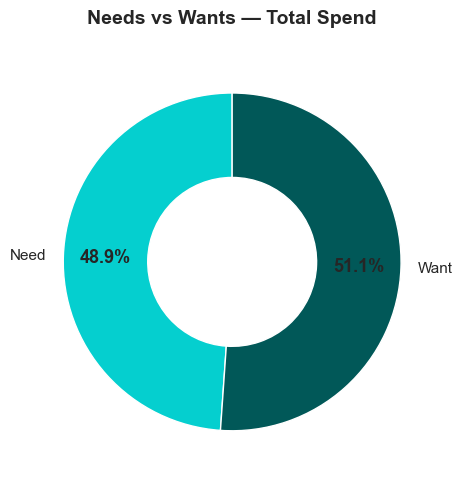

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

colors = ["#05CFCF", "#015858"]

wedges, texts, autotexts = ax.pie(
    Needs_Wants_sum.values,
    labels=Needs_Wants_sum.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight("bold")
    autotext.set_fontsize(13)

ax.set_title("Needs vs Wants — Total Spend", 
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart2_needs_wants_donut.png", dpi=150)
plt.show()

#### Key Findings So Far
##### 3 strong insights:
##### Insight 1: Shopping alone takes 22.34% of total budget - highest of all categories
##### Insight 2: Travel has the highest avg transaction at ₹5,520 - big but infrequent spends
##### Insight 3: March had worst spending discipline - 69.71% went to Wants

### **Time & Behaviour Analysis**

##### Q1: Which month had the highest total spending?

In [12]:
# Month wise total spending:
month_wise_spending = df_upi_cleaned.groupby(["Month_Num","Month_Name"])["Amount"].sum().sort_values(ascending=False)


print("Total Spending by Month: \n",month_wise_spending)

Total Spending by Month: 
 Month_Num  Month_Name
5          May           204490.78
6          June          192639.83
7          July          189755.23
10         October       176461.14
8          August        160444.01
9          September     148418.69
3          March         145085.94
11         November      133343.57
2          February      131892.07
1          January       119838.15
4          April         107910.06
12         December       95977.83
Name: Amount, dtype: float64


##### Q2: Which day of week sees the most transactions?

In [13]:
# Week Day wise Total Transaction:
weekday_wise_transaction = df_upi_cleaned.groupby(["Day_of_Week"])["Transaction_ID"].count().sort_values(ascending=False)

print("Total Transactions by day of week: \n",weekday_wise_transaction)

Total Transactions by day of week: 
 Day_of_Week
Sunday       175
Thursday     154
Wednesday    142
Monday       137
Friday       135
Tuesday      132
Saturday     125
Name: Transaction_ID, dtype: int64


##### Q3: Which day of week sees the highest spending amount?

In [14]:
# Weekday wise total spending:
weekday_wise_spending = df_upi_cleaned.groupby(["Day_of_Week"])["Amount"].sum().sort_values(ascending=False)

print("Total Spending by day of week : \n",weekday_wise_spending)

Total Spending by day of week : 
 Day_of_Week
Sunday       365623.18
Monday       267494.76
Thursday     265754.94
Friday       235964.23
Saturday     235781.57
Wednesday    225061.94
Tuesday      210576.68
Name: Amount, dtype: float64


##### Q4: Is spending trending up or down over months?

In [15]:
# Monthly Spending Trend
monthly_trend = df_upi_cleaned.groupby(
    ["Month_Num","Month_Name"
     ],as_index="Month_Num"
     ).agg(
         Total_Amount = ("Amount", "sum")).sort_index()

monthly_trend["MoM_Change"] = monthly_trend["Total_Amount"].diff().round(2)
monthly_trend["MoM_Change%"] = (monthly_trend["Total_Amount"].pct_change()*100).round(2)
print(monthly_trend)

                      Total_Amount  MoM_Change  MoM_Change%
Month_Num Month_Name                                       
1         January        119838.15         NaN          NaN
2         February       131892.07    12053.92        10.06
3         March          145085.94    13193.87        10.00
4         April          107910.06   -37175.88       -25.62
5         May            204490.78    96580.72        89.50
6         June           192639.83   -11850.95        -5.80
7         July           189755.23    -2884.60        -1.50
8         August         160444.01   -29311.22       -15.45
9         September      148418.69   -12025.32        -7.50
10        October        176461.14    28042.45        18.89
11        November       133343.57   -43117.57       -24.43
12        December        95977.83   -37365.74       -28.02


##### Q5: What is the average spend per day?

In [16]:
# day wise average spending
total_spending = df_upi_cleaned["Amount"].sum()
total_days = ((pd.to_datetime(df_upi_cleaned["Date"])).max() - (pd.to_datetime(df_upi_cleaned["Date"])).min()).days

avg_per_day = (total_spending/total_days).round(2)

print(f"Total Spend: ₹{total_spending}")
print(f"Total Days in the dataset: {total_days}")
print(f"Average Spend per day: ₹{avg_per_day}")

Total Spend: ₹1806257.3
Total Days in the dataset: 362
Average Spend per day: ₹4989.66


##### Q6: Which quarter had highest spending?

In [17]:
# Quarter wise Spending
qtr_spend = df_upi_cleaned.groupby(
    "Quarter")["Amount"
    ].sum().sort_values(ascending=False).round(2)

qtr_txn = df_upi_cleaned.groupby(
    "Quarter")["Transaction_ID"
    ].count()

qtr_summary = pd.DataFrame({
    "Total Spend" : qtr_spend,
    "Transactions" : qtr_txn,
    "Avg_Per_Txn" : (qtr_spend/qtr_txn).round(2)
})

print("\nQuarter Summary: \n",qtr_summary)


Quarter Summary: 
          Total Spend  Transactions  Avg_Per_Txn
Quarter                                        
Q1         396816.16           207      1916.99
Q2         505040.67           276      1829.86
Q3         498617.93           291      1713.46
Q4         405782.54           226      1795.50


**Q1 Answer:** May had the highest total spending of ₹2,04,490 —
nearly double the lowest month (December at ₹95,977).

**Q2 & Q3 Answer:** Sunday leads both — 175 transactions and 
₹3,65,623 total spend. Sundays appear to be the primary day 
for planned purchases and leisure spending.

**Q4 Answer:** May had the biggest MoM jump of +89.50% (₹96,580 
increase from April). Likely driven by summer vacation travel, 
online sales, and seasonal shopping in India.

**Q5 Answer:** Average spend per day is ₹4,989 over 362 days —
significantly high for a student profile.

**Q6 Answer:** Q2 had the highest total spend (₹5,05,040) with 
the most transactions (276) — driven largely by May's spike.

##### Chart 3 - Monthly Spending Trend : Line Chart

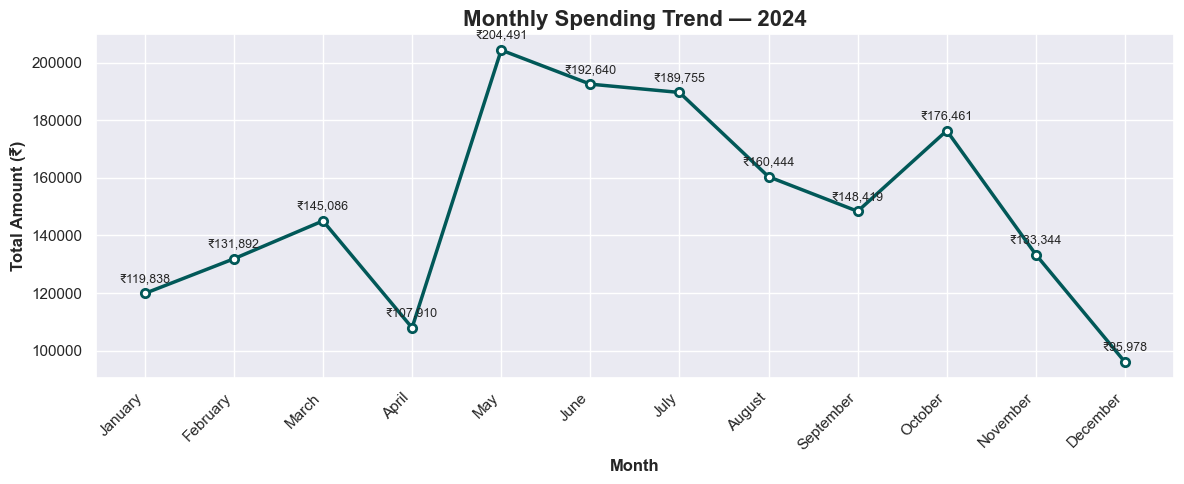

In [18]:
# Monthly Spending Trend
monthly_plot = df_upi_cleaned.groupby(
    ["Month_Num", "Month_Name"]
)["Amount"].sum().reset_index().sort_values("Month_Num")

plt.figure(figsize=(12, 5))

plt.plot(monthly_plot["Month_Name"],
         monthly_plot["Amount"],
         color="#015858",
         linewidth=2.5,
         marker="o",
         markersize=6,
         markerfacecolor="white",
         markeredgecolor="#015858",
         markeredgewidth=2)

# Adding data labels on each point
for i, row in monthly_plot.iterrows():
    plt.text(row["Month_Name"],
             row["Amount"] + 4000,
             f"₹{row['Amount']:,.0f}",
             ha="center",
             fontsize=9)

plt.title("Monthly Spending Trend — 2024", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Total Amount (₹)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart3_monthly_trend.png", dpi=150)
plt.show()

##### **Chart 3 Observation:** May had the highest spending spike of ₹2,04,490 - nearly double April's spend, driven by summer vacation and seasonal shopping.

#### Chart 4 - Spending by Day of Week : Bar Chart

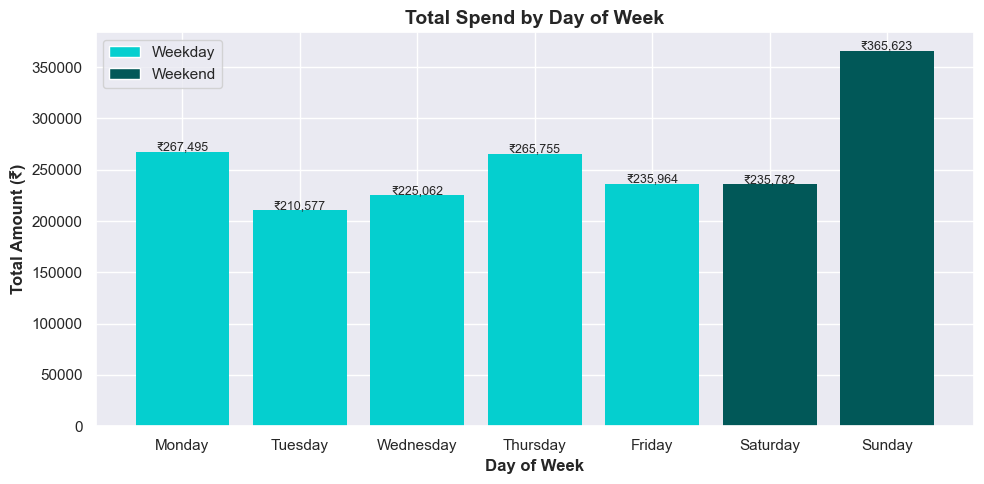

In [19]:
# Spending by Day of Week
day_order = ["Monday", "Tuesday", "Wednesday", 
             "Thursday", "Friday", "Saturday", "Sunday"]

day_spend_ordered = df_upi_cleaned.groupby(
    "Day_of_Week")["Amount"].sum().reindex(day_order).round(2)

plt.figure(figsize=(10, 5))

colors = ["#015858" if day in ["Saturday","Sunday"] 
          else "#05CFCF" for day in day_order]

bars = plt.bar(day_order, day_spend_ordered.values,
               color=colors, edgecolor="none")

# Value labels on top
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1500,
             f"₹{bar.get_height():,.0f}",
             ha="center", fontsize=9)
    
plt.title("Total Spend by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week",fontweight="bold")
plt.ylabel("Total Amount (₹)", fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#05CFCF", label="Weekday"),
                   Patch(facecolor="#015858", label="Weekend")]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart4_day_spend.png", dpi=150)
plt.show()



##### **Chart 4 Observation:** Sunday dominates both transaction count and total spend - confirming that weekends are the primary overspending trigger.

#### **ANOMALY DETECTION & SEABORN VISUALIZATIONS**

##### ANOMALY SUMMARY

In [20]:
# ANNOMALY SUMMARY
anomaly_df = df_upi_cleaned[df_upi_cleaned["Is_Anomaly"]=="Yes"]

print(f"Total Anomalies: {len(anomaly_df)}")
print(f"Anomaly%: {(len(anomaly_df)/len(df_upi_cleaned)*100):,.2f}%")
print(f"Total Anomaly Amount: ₹{anomaly_df["Amount"].sum()}")
print(f"Average Anomaly Amount: ₹{anomaly_df["Amount"].mean().round(2)}")
print(f"Highest Anomaly Amount: ₹{anomaly_df["Amount"].max()}")



Total Anomalies: 35
Anomaly%: 3.50%
Total Anomaly Amount: ₹372921.2
Average Anomaly Amount: ₹10654.89
Highest Anomaly Amount: ₹30870.93


##### **Which categories have most anomalies?**

In [21]:
# Category Wise Anomaly Detection
category_anomaly = anomaly_df.groupby("Category")["Transaction_ID"].count().sort_values(ascending=False)
print("Anomaly by Category: \n",category_anomaly)

Anomaly by Category: 
 Category
Education            12
Travel               12
Shopping              4
Groceries             2
Bills & Utilities     2
Miscellaneous         2
Health & Medical      1
Name: Transaction_ID, dtype: int64


##### Most Anomalies are in Education (12) and Travel (12)

#####  **Did anomalies happen more in specific months?**

In [22]:
# Anomaly by Month
monthly_anomaly = anomaly_df.groupby(["Month_Num","Month_Name"])["Transaction_ID"].count().sort_values(ascending=False)
print("Anomaly by Month: \n",monthly_anomaly)

Anomaly by Month: 
 Month_Num  Month_Name
5          May           7
6          June          5
10         October       4
2          February      3
3          March         3
7          July          3
11         November      3
9          September     3
8          August        2
12         December      2
Name: Transaction_ID, dtype: int64


##### **Top 10 anomaly transactions**

In [23]:
# Top 10 anomaly transactions
top_10_anomaly = anomaly_df.nlargest(10, "Amount")[
    ["Date","Category","Merchant","Amount","Payment_Mode"]]

print("Top-10 Anomaly Transactions: \n",top_10_anomaly)

Top-10 Anomaly Transactions: 
            Date           Category      Merchant    Amount Payment_Mode
225  2024-03-08             Travel           OYO  30870.93         GPay
46   2024-10-23             Travel           OYO  24072.67      PhonePe
43   2024-05-23          Education  College Fees  20021.46      PhonePe
653  2024-09-17           Shopping        Amazon  17647.18      PhonePe
570  2024-05-06           Shopping        Meesho  16897.50      PhonePe
903  2024-03-24           Shopping          Ajio  15537.45      PhonePe
501  2024-02-08           Shopping        Amazon  15322.12      PhonePe
973  2024-10-12  Bills & Utilities        Airtel  13831.82      PhonePe
178  2024-06-24  Bills & Utilities      MPPKVVCL  13454.62   Amazon Pay
918  2024-11-26          Groceries     BigBasket   9167.41      PhonePe


##### **Chart 5: Anomaly vs Normal Spending Comparison**

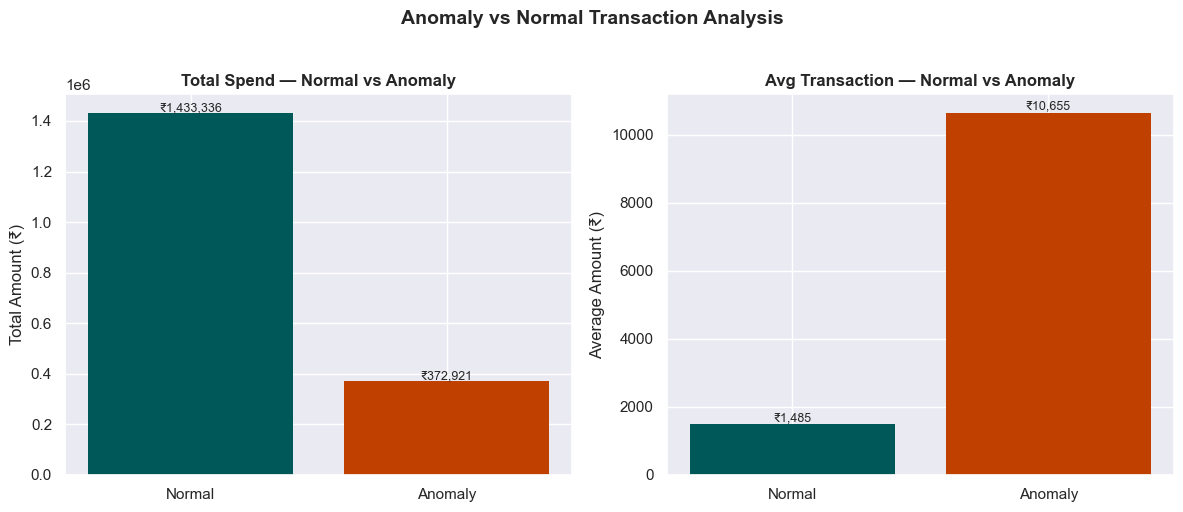

In [24]:
# Chart 5 - Anomaly vs Normal Spending
anomaly_summary = df_upi_cleaned.groupby("Is_Anomaly")["Amount"].agg(
    Total="sum", Count="count", Average="mean").round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Total Spend
axes[0].bar(["Normal", "Anomaly"],
            anomaly_summary["Total"].values,
            color=["#015858", "#C04000"],
            edgecolor="none")
axes[0].set_title("Total Spend — Normal vs Anomaly", fontweight="bold")
axes[0].set_ylabel("Total Amount (₹)")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5000,
                 f"₹{bar.get_height():,.0f}",
                 ha="center", fontsize=9)

# Right — Average Transaction
axes[1].bar(["Normal", "Anomaly"],
            anomaly_summary["Average"].values,
            color=["#015858", "#C04000"],
            edgecolor="none")
axes[1].set_title("Avg Transaction — Normal vs Anomaly", fontweight="bold")
axes[1].set_ylabel("Average Amount (₹)")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f"₹{bar.get_height():,.0f}",
                 ha="center", fontsize=9)

plt.suptitle("Anomaly vs Normal Transaction Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart5_anomaly_comparison.png", dpi=150)
plt.show()

##### **Chart 6: Seaborn Heatmap (Category vs Day of Week)**

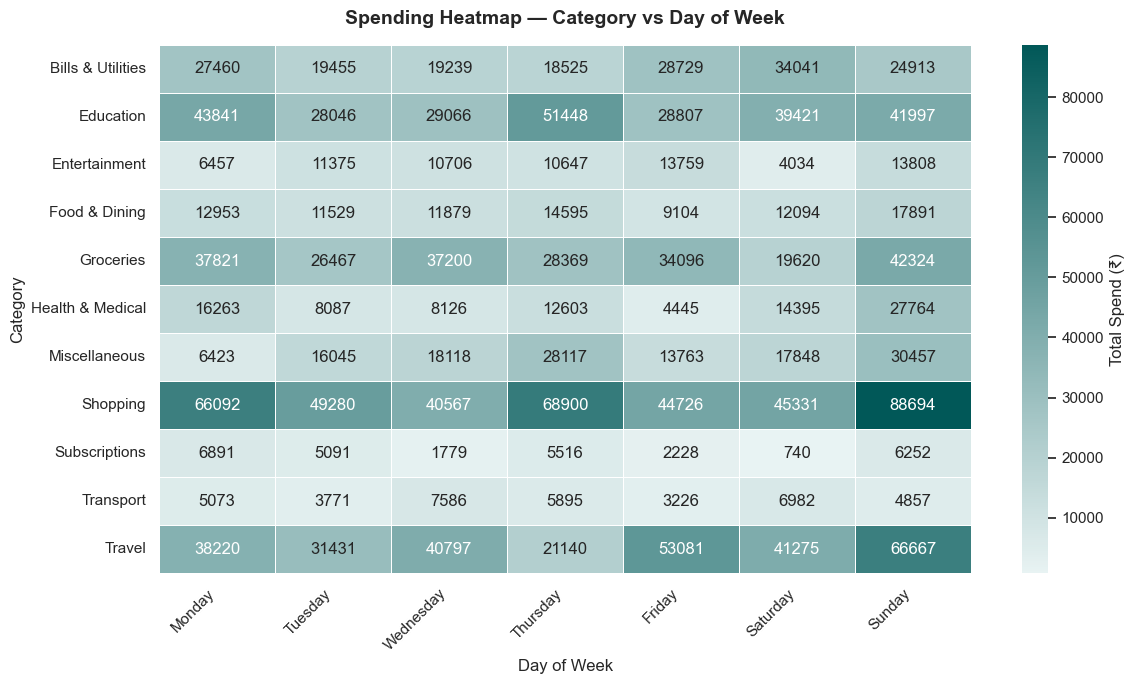

In [25]:
# Chart 6 - Heatmap: Category vs Day of Week
day_order = ["Monday","Tuesday","Wednesday",
             "Thursday","Friday","Saturday","Sunday"]

heatmap_data = df_upi_cleaned.groupby(
    ["Category","Day_of_Week"])["Amount"].sum().unstack()[day_order].round(0)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data,
            cmap = sns.light_palette("#015858", as_cmap=True),
            fmt=".0f",
            annot=True,
            linewidths=0.5,
            cbar_kws={"label": "Total Spend (₹)"})

plt.title("Spending Heatmap — Category vs Day of Week",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of Week")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart6_heatmap.png", dpi=150)
plt.show()

##### **Chart 7: Box Plot (Transaction Distribution by Category)**

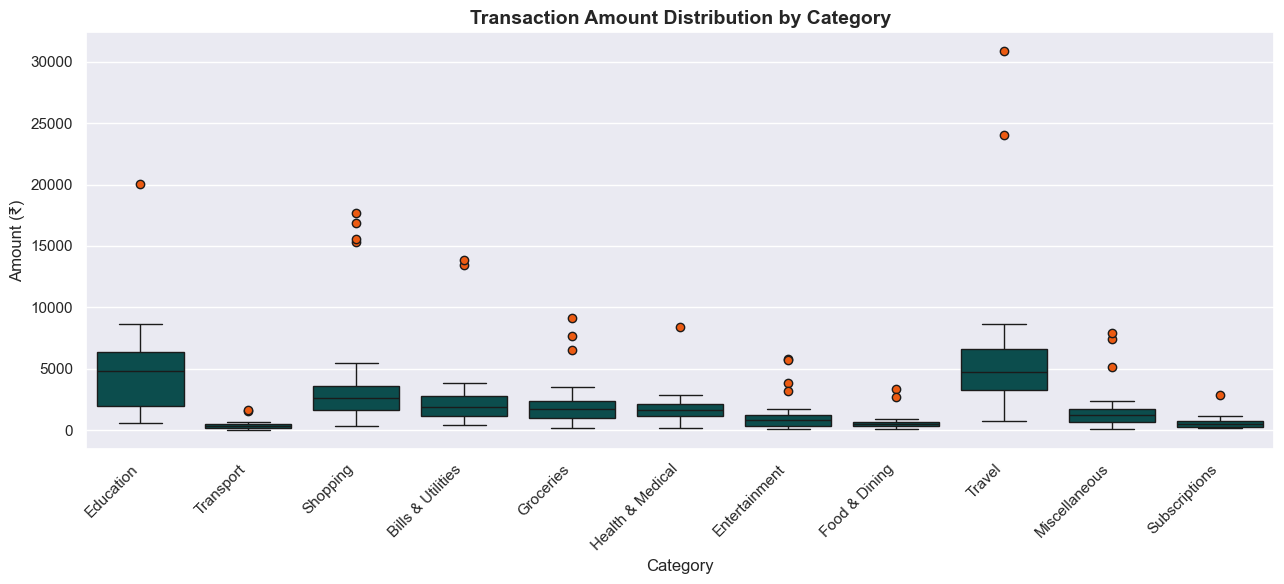

In [26]:
# Chart 7 - Box Plot: Amount distribution per category
plt.figure(figsize=(13, 6))
sns.boxplot(data=df_upi_cleaned,
            x="Category",
            y="Amount",
            color="#015858",
            linewidth=1,
            flierprops={"marker":"o",
                        "markerfacecolor":"#EC5B12",
                        "markersize":6})

plt.title("Transaction Amount Distribution by Category",
          fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart7_boxplot.png", dpi=150)
plt.show()

#### Box Plot Analysis — Key Observations

1. **Education has the tallest box (widest spread)**
   Education transactions vary wildly from a few hundred rupees (books, stationery) to thousands (course fees, college payments). This means Education spending is highly unpredictable month to month.

2. **Shopping has the most outliers (4 red dots)**
   Shopping has the most anomalous transactions occasional very large purchases like electronics, festive shopping, or bulk orders spike far above normal spending. These are the transactions worth investigating.

3. **Education has the highest median line**
   The typical Education transaction is higher than any other category. Even a routine Education payment costs more than a routine Food, Transport or Entertainment transaction.

**Combined Insight:**
Education is the most expensive and unpredictable category on a per-transaction basis, while Shopping is the most prone to impulsive high-value purchases. Together they represent the two biggest financial risk areas in this spending profile.

#### **SAVING INTELLIGENCE & BUSINESS RECOMMENDATIONS**

#####  Current Spending Benchmark

In [31]:
total_months = df_upi_cleaned["Month_Num"].nunique()
avg_monthly_spend = (total_spending/total_months).round(2)

print(f"Total Anual Soend: ₹ {total_spending}")
print(f"Total Months: {total_months}")
print(f"Average Spending per Month: ₹ {avg_monthly_spend}")

Total Anual Soend: ₹ 1806257.3
Total Months: 12
Average Spending per Month: ₹ 150521.44


##### Which Want categories grew most month over month?

In [33]:
# Want categories month over month growth
want_monthly = df_upi_cleaned[df_upi_cleaned["Type"]=="Want"].groupby(
    ["Month_Num","Category"])["Amount"].sum().unstack().fillna(0)

# Calculate growth from first to last month
want_growth_mom = ((want_monthly.iloc[-1] - want_monthly.iloc[0]) / 
                   want_monthly.iloc[0] * 100).round(2).sort_values(ascending=False)

print("Want Category Growth (Jan to Dec):\n", want_growth_mom)

Want Category Growth (Jan to Dec):
 Category
Subscriptions    239.61
Travel           236.27
Entertainment     87.11
Miscellaneous    -23.08
Shopping         -62.19
dtype: float64


##### How much can be saved by reducing top Want categories?

In [37]:
# Saving Opportunity Calculator
want_spend = df_upi_cleaned[df_upi_cleaned["Type"] == "Want"].groupby(
    "Category")["Amount"].sum().sort_values(ascending=False).round(2)

print("Current Annual Want Spending:")
print(want_spend)
print()

# If reduced by 20%
for category, amount in want_spend.items():
    saving = (amount * 0.20)
    print(f"Reduce {category} by 20% → Save ₹{saving:,.2f} annually")

Current Annual Want Spending:
Category
Shopping         403589.41
Travel           292609.64
Miscellaneous    130772.23
Entertainment     67622.51
Subscriptions     28497.43
Name: Amount, dtype: float64

Reduce Shopping by 20% → Save ₹80,717.88 annually
Reduce Travel by 20% → Save ₹58,521.93 annually
Reduce Miscellaneous by 20% → Save ₹26,154.45 annually
Reduce Entertainment by 20% → Save ₹13,524.50 annually
Reduce Subscriptions by 20% → Save ₹5,699.49 annually


#####  Ideal Monthly Budget Recommendation

In [40]:
# Ideal Budget Recommendation based on 50/30/20 rule
# 50% Needs, 30% Wants, 20% Savings

print("=== IDEAL BUDGET RECOMMENDATION ===")
print(f"Based on Average Monthly Income Estimate: ₹{avg_monthly_spend:,.2f}\n")

ideal_needs = (avg_monthly_spend * 0.50).round(2)
ideal_wants = (avg_monthly_spend * 0.30).round(2)
ideal_savings = (avg_monthly_spend * 0.20).round(2)

actual_needs = (df_upi_cleaned[df_upi_cleaned["Type"] == "Need"]["Amount"].sum() / total_months).round(2)
actual_wants = (df_upi_cleaned[df_upi_cleaned["Type"] == "Want"]["Amount"].sum() / total_months).round(2)

print(f"{'Category':<12} {'Ideal':>12} {'Actual':>12} {'Difference':>12}")
print("-" * 50)
print(f"{'Needs':<12} ₹{ideal_needs:>10,.2f} ₹{actual_needs:>10,.2f} ₹{(actual_needs - ideal_needs):>10,.2f}")
print(f"{'Wants':<12} ₹{ideal_wants:>10,.2f} ₹{actual_wants:>10,.2f} ₹{(actual_wants - ideal_wants):>10,.2f}")
print(f"{'Savings':<12} ₹{ideal_savings:>10,.2f} {'₹0.00':>12} {'-':>12}")

=== IDEAL BUDGET RECOMMENDATION ===
Based on Average Monthly Income Estimate: ₹150,521.44

Category            Ideal       Actual   Difference
--------------------------------------------------
Needs        ₹ 75,260.72 ₹ 73,597.17 ₹ -1,663.55
Wants        ₹ 45,156.43 ₹ 76,924.27 ₹ 31,767.84
Savings      ₹ 30,104.29        ₹0.00            -


##### Calculate Saving Score (1-10)

In [42]:
# Saving Score Calculation
needs_ratio = (df_upi_cleaned[df_upi_cleaned["Type"] == "Need"]["Amount"].sum() / total_spending)
anomaly_count = len(df_upi_cleaned[df_upi_cleaned["Is_Anomaly"] == "Yes"])
anomaly_penalty = (anomaly_count / len(df_upi_cleaned)) * 10

# Score logic
base_score = needs_ratio * 10
final_score = (base_score - anomaly_penalty).round(1)
final_score = max(1, min(10, final_score))

print("=== SAVING SCORE BREAKDOWN ===")
print(f"Needs Ratio: {(needs_ratio*100).round(2)}%")
print(f"Base Score (from Needs Ratio): {base_score.round(2)}")
print(f"Anomaly Penalty: -{anomaly_penalty:.2f}")
print(f"\n⭐ Final Saving Score: {final_score} / 10")

if final_score >= 7:
    print("Assessment: Good spending habits ✅")
elif final_score >= 5:
    print("Assessment: Average — room for improvement ⚠️")
else:
    print("Assessment: Poor spending discipline ❌")

=== SAVING SCORE BREAKDOWN ===
Needs Ratio: 48.89%
Base Score (from Needs Ratio): 4.89
Anomaly Penalty: -0.35

⭐ Final Saving Score: 4.5 / 10
Assessment: Poor spending discipline ❌


##### Business Recommendations

In [43]:
# Top 3 Recommendations
print("=== TOP 3 RECOMMENDATIONS ===\n")

print("1. REDUCE SHOPPING SPEND")
shopping_annual = df_upi_cleaned[df_upi_cleaned["Category"] == "Shopping"]["Amount"].sum()
print(f"   Shopping = ₹{shopping_annual:,.2f} annually (22.34% of budget)")
print(f"   Cutting by 20% saves ₹{(shopping_annual*0.20):,.2f} per year\n")

print("2. CONTROL SUNDAY SPENDING")
sunday_spend = df_upi_cleaned[df_upi_cleaned["Day_of_Week"] == "Sunday"]["Amount"].sum()
print(f"   Sunday alone = ₹{sunday_spend:,.2f} total spend")
print(f"   Set a Sunday budget cap to control weekend impulse buying\n")

print("3. PLAN FOR SEASONAL SPIKES")
may_spend = df_upi_cleaned[df_upi_cleaned["Month_Name"] == "May"]["Amount"].sum()
print(f"   May spending spiked to ₹{may_spend:,.2f} (+89.50% MoM)")
print(f"   Build a summer fund in advance to avoid financial stress")

=== TOP 3 RECOMMENDATIONS ===

1. REDUCE SHOPPING SPEND
   Shopping = ₹403,589.41 annually (22.34% of budget)
   Cutting by 20% saves ₹80,717.88 per year

2. CONTROL SUNDAY SPENDING
   Sunday alone = ₹365,623.18 total spend
   Set a Sunday budget cap to control weekend impulse buying

3. PLAN FOR SEASONAL SPIKES
   May spending spiked to ₹204,490.78 (+89.50% MoM)
   Build a summer fund in advance to avoid financial stress


#### **Chart 8: Saving Opportunity Bar Chart**

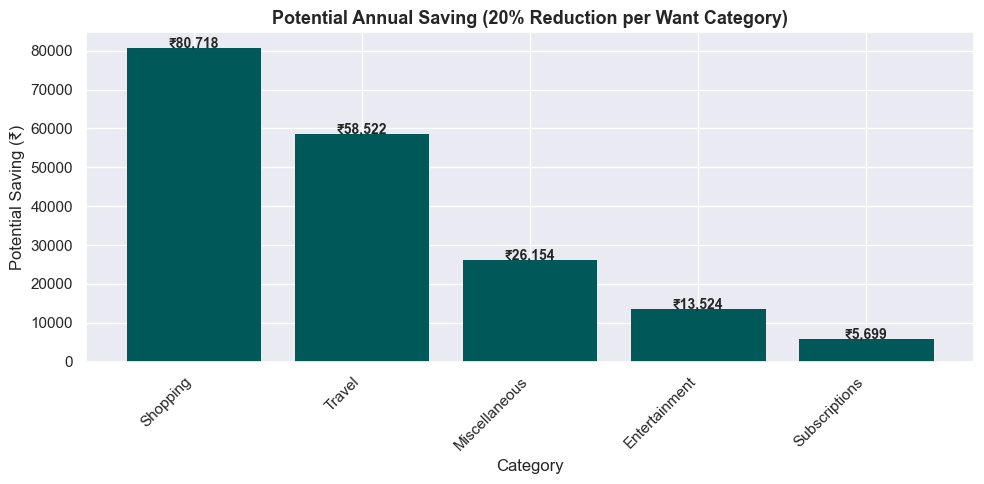

In [50]:
# Chart 8 - Saving Opportunity by Want Category
want_spend = df_upi_cleaned[df_upi_cleaned["Type"] == "Want"].groupby(
    "Category")["Amount"].sum().sort_values(ascending=False).round(2)

saving_20pct = (want_spend * 0.20).round(2)

plt.figure(figsize=(10, 5))
bars = plt.bar(want_spend.index, saving_20pct.values,
               color="#015858", edgecolor="none")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f"₹{bar.get_height():,.0f}",
             ha="center", fontsize=10, fontweight="bold")

plt.title("Potential Annual Saving (20% Reduction per Want Category)",
          fontsize=13, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Potential Saving (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"E:\Data Analystics\PROJECTS FOR PORTFOLIO\PROJECT 01_UPI-spending-analyzer\Visuals\chart8_saving_opportunity.png", dpi=150)
plt.show()